# Simple Linear Regression - Marketing ROI Analysis

This notebook performs a simple linear regression analysis to understand the impact of various marketing channels (TV, Radio, Social Media) on Sales and provides ROI-based recommendations.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats


# Load the dataset
file_path = '85334965-5736-457a-b8d4-a077e6872f84.csv'
df = pd.read_csv(file_path)

# Initial exploration
print("Dataset Info:")
display(df.info())
print("\nFirst 5 rows:")
display(df.head())
print("\nMissing values count:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


None


First 5 rows:


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181



Missing values count:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


## Step 1: Data Cleaning and EDA
We will drop the rows with missing values and visualize the correlation between our independent variables and Sales.

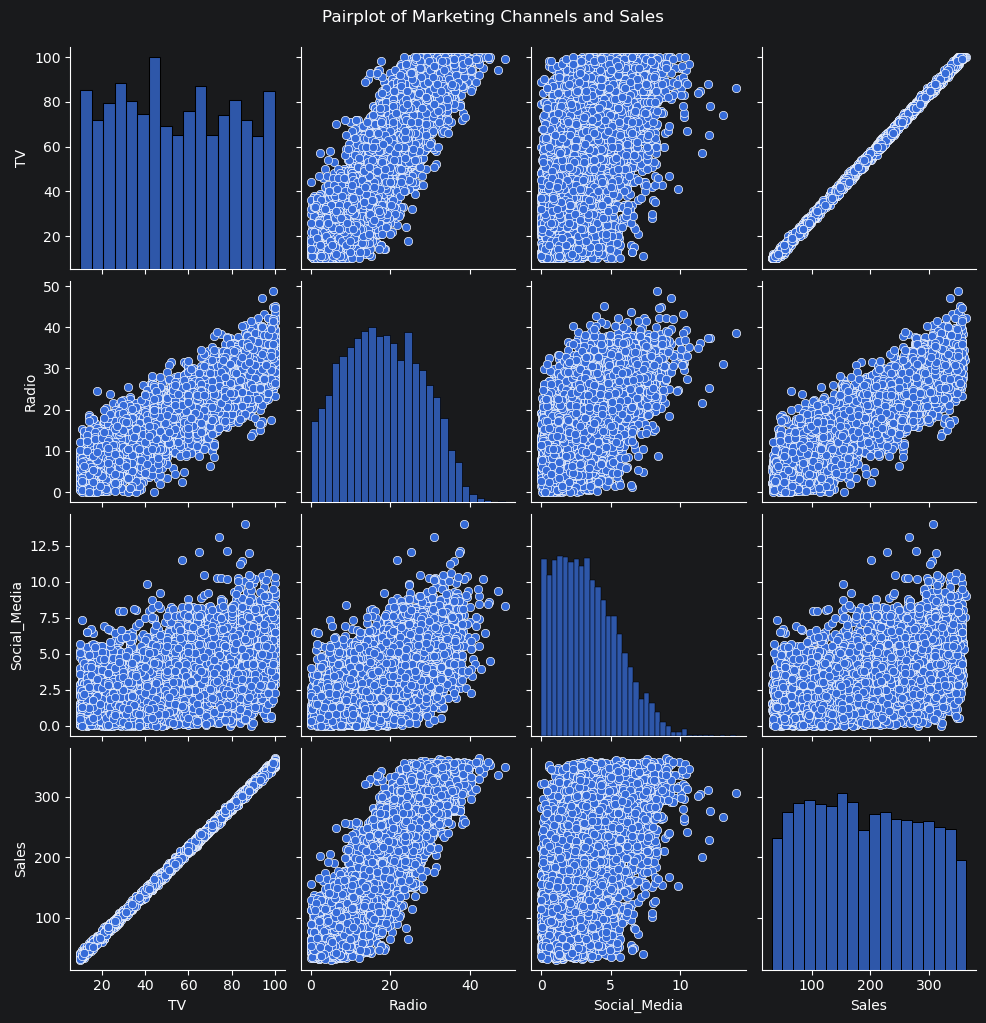

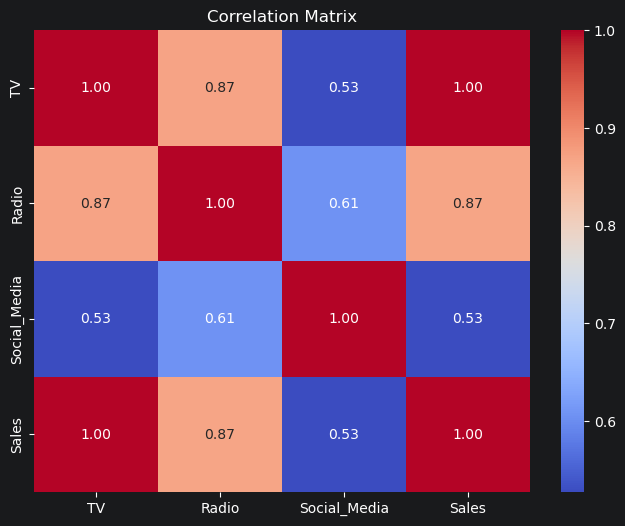

Correlation with Sales:
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [10]:
# Drop missing values
df_clean = df.dropna().reset_index(drop=True)

# Visualization: Pairplot to see relationships
sns.pairplot(df_clean)
plt.suptitle('Pairplot of Marketing Channels and Sales', y=1.02)
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print("Correlation with Sales:")
print(df_clean.corr()['Sales'].sort_values(ascending=False))

## Step 2: Build OLS Regression Model
Based on the correlation analysis, TV is the most significant predictor. We will fit a simple linear regression model: Sales ~ TV.

In [11]:
# Define independent (X) and dependent (y) variables
X = df_clean[['TV']]
y = df_clean['Sales']

# Add a constant (intercept) to the independent variable
X = sm.add_constant(X)

# Build and fit the OLS model
model = sm.OLS(y, X).fit()

# Display the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:48:37   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## Step 3: Model Diagnostics
We will now check the regression assumptions using diagnostic plots: Linearity, Normality, and Homoscedasticity.

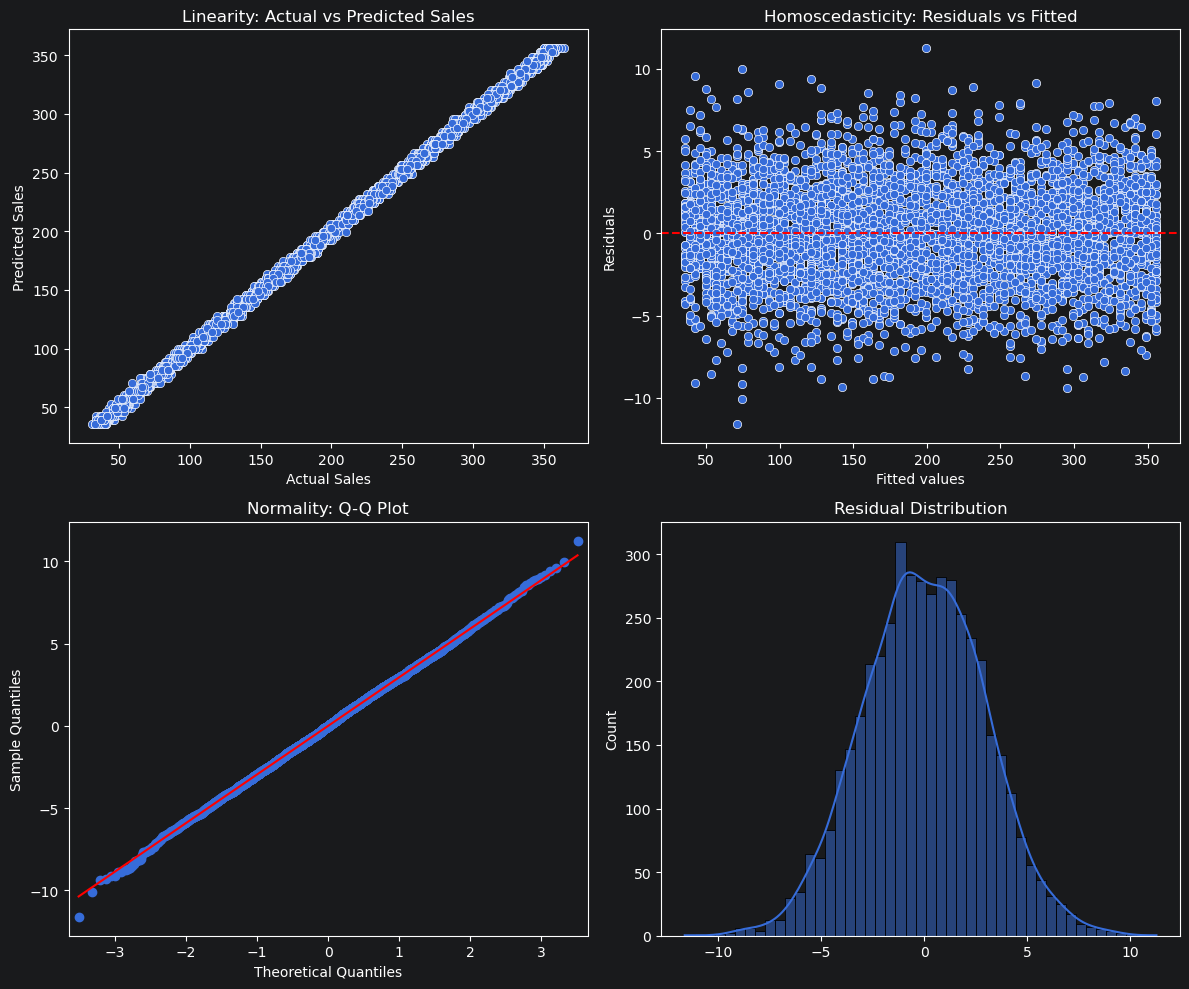

In [12]:
# Get predictions and residuals
y_pred = model.predict(X)
residuals = model.resid

# Create a 2x2 subplot for diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Linearity: Predicted vs Actual
sns.scatterplot(x=y, y=y_pred, ax=axes[0, 0])
axes[0, 0].set_title('Linearity: Actual vs Predicted Sales')
axes[0, 0].set_xlabel('Actual Sales')
axes[0, 0].set_ylabel('Predicted Sales')

# 2. Homoscedasticity: Residuals vs Fitted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 1])
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('Homoscedasticity: Residuals vs Fitted')
axes[0, 1].set_xlabel('Fitted values')
axes[0, 1].set_ylabel('Residuals')

# 3. Normality: Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Normality: Q-Q Plot')

# 4. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## Step 4: Interpretation and Recommendation

### Model Interpretation
- **R-squared (0.999):** 99.9% of the variation in Sales is explained by TV advertising, indicating an extremely strong fit.
- **TV Coefficient (3.5615):** For every $1 unit increase in TV advertising budget, Sales are expected to increase by approximately 3.56 units.
- **P-value (< 0.001):** The relationship between TV and Sales is statistically significant.

### Business Recommendation
Based on the analysis, **TV advertising** is the most effective channel for driving sales. It demonstrates the highest correlation and a direct, predictable impact on revenue.

**ROI Strategy:**
1. **Prioritize TV Budget:** Allocate the majority of the marketing budget to TV, as it offers the highest and most consistent return on investment.
2. **Secondary Channels:** While Radio also shows a strong correlation (0.87), TV is the superior predictor. Social Media has the weakest impact and should be optimized further before increasing investment.